In [1]:
import pandas as pd
import re
import emoji
import numpy as np
import concurrent.futures
import multiprocessing
import os
import fasttext
import urllib.request


MODEL_FILE = 'lid.176.ftz' # Versi compressed, lebih ringan

def download_fasttext_model():
    if not os.path.exists(MODEL_FILE):
        print("Mendownload model FastText")
        url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz"
        urllib.request.urlretrieve(url, MODEL_FILE)
        print("Model selesai didownload.")

# Pastikan model ada
download_fasttext_model()

# Variabel global untuk model FastText di setiap worker
ft_model = None

def init_worker():
    """Inisialisasi model di setiap worker process"""
    global ft_model
    # Suppress warning dari fasttext
    fasttext.FastText.eprint = lambda x: None
    ft_model = fasttext.load_model(MODEL_FILE)

# ==========================================
# 1. PRE-COMPILE REGEX
# ==========================================
# Menggabungkan regex agar hanya 1-2 pass, bukan berkali-kali
re_url = re.compile(r"http\S+|www\S+|https\S+")
re_mentions = re.compile(r"@\w+")
# Regex untuk karakter non-alphanumeric (kecuali tanda baca dasar)
re_cleanup = re.compile(r"[^a-zA-Z0-9\s.,!?']")
re_whitespace = re.compile(r"\s+")

# ==========================================
# 2. FUNGSI PEMROSESAN CEPAT
# ==========================================

def detect_language_fasttext_batch(text_list):
    """Mendeteksi bahasa menggunakan FastText (Batch processing)"""
    # Bersihkan newline agar fasttext tidak bingung
    cleaned_list = [str(t).replace("\n", " ") for t in text_list]
    
    # FastText bisa prediksi list sekaligus (sangat cepat)
    # k=1 artinya ambil 1 prediksi teratas
    predictions = ft_model.predict(cleaned_list, k=1) 
    
    # Format output: (('__label__en',), ...) -> ambil 'en'
    results = [label[0].replace("__label__", "") for label in predictions[0]]
    return results

def clean_text_optimized(text):
    """Fungsi cleaning yang sudah dioptimasi regex-nya"""
    text = str(text)
    # 1. Hapus Emoji (paling berat, lakukan dulu atau gunakan library demoji jika emoji library lambat)
    text = emoji.replace_emoji(text, replace=' ')
    
    # 2. Regex yang sudah di-compile (Jauh lebih cepat)
    text = re_url.sub("", text)
    text = re_mentions.sub("", text)
    text = re_cleanup.sub("", text)
    
    # 3. Lowercase & Whitespace
    text = text.lower()
    text = re_whitespace.sub(" ", text).strip()
    return text

# ==========================================
# 3. WORKER WRAPPERS
# ==========================================

def process_lang_chunk(chunk):
    # Langsung panggil fungsi batch fasttext
    return detect_language_fasttext_batch(chunk.tolist())

def process_clean_chunk(chunk):
    return chunk.apply(clean_text_optimized)

# ==========================================
# 4. MAIN ENGINE
# ==========================================

def parallel_execute(series, func, is_batch=False):
    num_cores = multiprocessing.cpu_count()
    # Kurangi jumlah chunk. Terlalu banyak chunk = overhead tinggi.
    # 4x jumlah core biasanya sweet spot.
    num_chunks = num_cores * 4 
    chunks = np.array_split(series, num_chunks)
    
    results = []
    print(f"   -> Menggunakan {num_cores} Cores dengan FastText/Optimized Regex...")
    
    # Gunakan context manager dengan initializer untuk load model
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_cores, initializer=init_worker) as executor:
        # Gunakan executor.map agar urutan hasil SAMA dengan input (tidak perlu sort_index manual)
        # Ini lebih efisien memori dan CPU daripada as_completed + sort
        results_gen = executor.map(func, chunks)
        
        # Tampilkan progress sederhana (tqdm di executor.map agak tricky, kita list-kan saja)
        for res in results_gen:
            results.append(res)
            
    # Gabungkan hasil
    if is_batch:
        # Jika hasil berupa list of lists (dari fasttext batch)
        flat_results = [item for sublist in results for item in sublist]
        return pd.Series(flat_results, index=series.index)
    else:
        return pd.concat(results)

if __name__ == '__main__':
    # --- LOAD DATA ---
    FILENAME = "/kaggle/input/komentar-yt/youtube_comments_BERSIH.csv"
    
    # Cek dummy data jika file tidak ada (untuk testing kode ini jalan)
    if not os.path.exists(FILENAME):
        print("File tidak ditemukan")
    else:
        print(f"Membaca file: {FILENAME}")
        df = pd.read_csv(FILENAME)
        
    df['text'] = df['text'].astype(str)
    print(f"Total Data: {len(df)}")

    # --- A. DETEKSI BAHASA (FASTTEXT) ---
    print("\n[1/4] Mendeteksi Bahasa (FastText)...")
    # FastText sangat cepat, bahkan single core pun ngebut. 
    # Tapi kita pakai parallel biar konsisten.
    df['lang'] = parallel_execute(df['text'], process_lang_chunk, is_batch=True)
    
    # Filter Inggris
    df_english = df[df['lang'] == 'en'].copy()
    print(f"Sisa Data English: {len(df_english)}")

    # --- B. CLEANING TEXT (PARALLEL REGEX) ---
    if len(df_english) > 0:
        print("\n[2/4] Membersihkan Text (Optimized Regex)...")
        df_english['clean_text'] = parallel_execute(df_english['text'], process_clean_chunk)
        df_clean = df_english[df_english['clean_text'] != ""].copy()

        # --- C. FILTER LANJUTAN ---
        print("\n[3/4] Filter Komentar Pendek...")
        # Vectorized operation (Jauh lebih cepat dari .apply untuk hitung kata)
        # Menghitung spasi + 1 lebih cepat daripada split list
        df_clean['word_count'] = df_clean['clean_text'].str.count(' ') + 1
        df_final = df_clean[df_clean['word_count'] >= 3].copy()
        
        df_final['published_at'] = pd.to_datetime(df_final['published_at'], errors='coerce')
        df_final = df_final.dropna(subset=['published_at']).sort_values(by='published_at').reset_index(drop=True)

        # --- SIMPAN ---
        print("\n[4/4] Selesai!")
        print(df_final[['published_at', 'clean_text']].head())
        df_final.to_csv("youtube_comments_READY_FOR_BERT.csv", index=False)
    else:
        print("Tidak ada data bahasa Inggris ditemukan.")

Mendownload model FastText
Model selesai didownload.
Membaca file: /kaggle/input/komentar-yt/youtube_comments_BERSIH.csv
Total Data: 814483

[1/4] Mendeteksi Bahasa (FastText)...
   -> Menggunakan 4 Cores dengan FastText/Optimized Regex...


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Sisa Data English: 742661

[2/4] Membersihkan Text (Optimized Regex)...
   -> Menggunakan 4 Cores dengan FastText/Optimized Regex...


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)



[3/4] Filter Komentar Pendek...

[4/4] Selesai!
               published_at                                         clean_text
0 2007-06-28 20:15:20+00:00  chinese cars are crap, im scareeeed here in me...
1 2007-06-28 20:15:20+00:00  chinese cars are crap, im scareeeed here in me...
2 2007-06-30 15:43:10+00:00  personaly love american, well, actualy just fo...
3 2007-06-30 15:43:10+00:00  personaly love american, well, actualy just fo...
4 2007-07-01 11:50:32+00:00  you testd a tianma model, tianma vehicle sucks...


In [2]:
# Cek berapa banyak duplikat yang ada
total_rows = len(df_final)
duplicated_rows = df_final['clean_text'].duplicated().sum()

print(f"Total baris sebelum hapus duplikat: {total_rows}")
print(f"Jumlah baris duplikat yang ditemukan (berdasarkan clean_text): {duplicated_rows}")

# Menghapus baris duplikat, hanya menyisakan kemunculan pertama (keep='first')
df_final_dedup = df_final.drop_duplicates(subset=['clean_text'], keep='first').copy()

final_rows = len(df_final_dedup)
print(f"Total baris setelah hapus duplikat: {final_rows}")
print(f"Data yang hilang: {total_rows - final_rows}")

Total baris sebelum hapus duplikat: 681632
Jumlah baris duplikat yang ditemukan (berdasarkan clean_text): 332596
Total baris setelah hapus duplikat: 349036
Data yang hilang: 332596


In [4]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from tqdm import tqdm
import math

# ==========================================
# 1. SETUP MODEL (HANYA SEKALI LOAD)
# ==========================================
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
BATCH_SIZE = 64  # Bisa disesuaikan

# Device check
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device("cuda:0")  # Master device
    multi_gpu = True
    print(f"Multiple GPUs detected: {torch.cuda.device_count()}, using DataParallel")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    multi_gpu = False
    print(f"Using single device: {device}")

print("Loading Model BERT...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Pakai DataParallel jika ada >1 GPU
if multi_gpu:
    model = torch.nn.DataParallel(model)

model.to(device)
model.eval()

# ==========================================
# 2. FUNGSI SCORING (BATCHING, GPU)
# ==========================================
def run_bert_safe_batching_multi_gpu(text_list, batch_size=32):
    scores = []
    n_batches = math.ceil(len(text_list) / batch_size)
    
    for i in tqdm(range(n_batches), desc="BERT Scoring"):
        batch_texts = text_list[i * batch_size : (i + 1) * batch_size]
        batch_texts = [str(t) if pd.notna(t) else "" for t in batch_texts]

        # Tokenisasi
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = softmax(outputs.logits.cpu().numpy(), axis=1)
        scores.extend(probs[:, 1])  # Ambil skor Positif

    return scores

# ==========================================
# 3. EKSEKUSI
# ==========================================
if __name__ == "__main__":
    print(f"Total Data: {len(df_final_dedup)}")
    list_text = df_final_dedup['clean_text'].tolist()

    sentiment_scores = run_bert_safe_batching_multi_gpu(list_text, batch_size=BATCH_SIZE)
    df_final_dedup['sentiment_score'] = sentiment_scores

    print(df_final_dedup[['clean_text', 'sentiment_score']].head())
    df_final_dedup.to_csv("hasil_sentiment_final.csv", index=False)


Multiple GPUs detected: 2, using DataParallel
Loading Model BERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

2025-11-22 06:04:42.886874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763791483.082209      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763791483.136015      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Total Data: 349036


BERT Scoring: 100%|██████████| 5454/5454 [15:51<00:00,  5.73it/s]


                                          clean_text  sentiment_score
0  chinese cars are crap, im scareeeed here in me...         0.000839
2  personaly love american, well, actualy just fo...         0.998542
4  you testd a tianma model, tianma vehicle sucks...         0.979364
6  well yea its a beat up 2 year old car... you k...         0.267125
8  i dont know what you mean?? if u r talking abo...         0.070307


   year  sentiment_score
0  2007         0.381315
1  2008         0.302500
2  2009         0.213272
3  2010         0.221565
4  2011         0.235274


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


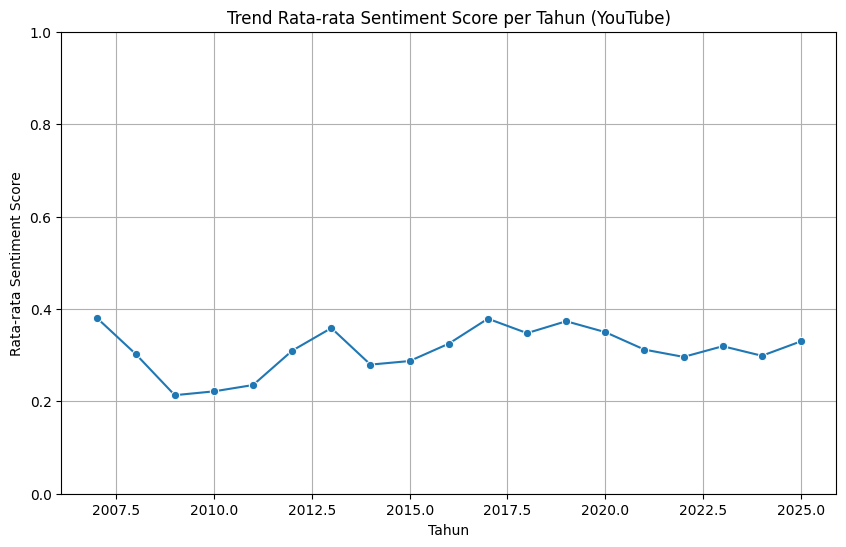

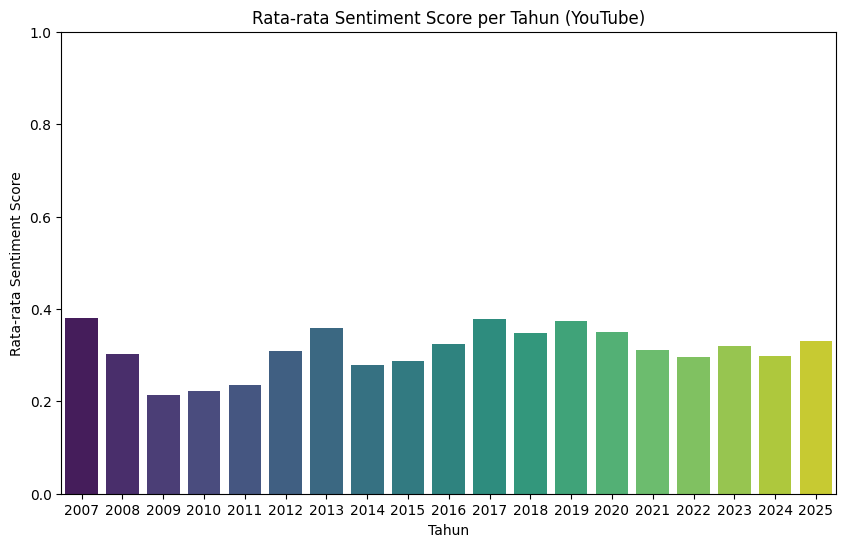

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# LOAD DATA
# ===========================
df = pd.read_csv("/kaggle/working/hasil_sentiment_final.csv")

if 'sentiment_score' not in df.columns:
    raise ValueError("Kolom 'sentiment_score' tidak ada!")

if 'published_at' not in df.columns:
    raise ValueError("Kolom 'published_at' tidak ada!")

# ===========================
# KONVERSI KE DATETIME
# ===========================
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')

# Buat kolom year
df['year'] = df['published_at'].dt.year

# ===========================
# AGGREGASI PER TAHUN
# ===========================
df_year = df.groupby('year')['sentiment_score'].mean().reset_index()
print(df_year.head())

# ===========================
# VISUALISASI TREND
# ===========================
plt.figure(figsize=(10,6))
sns.lineplot(data=df_year, x='year', y='sentiment_score', marker='o')
plt.title("Trend Rata-rata Sentiment Score per Tahun (YouTube)")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Sentiment Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Optional: bar chart per tahun
plt.figure(figsize=(10,6))
sns.barplot(data=df_year, x='year', y='sentiment_score', palette='viridis')
plt.title("Rata-rata Sentiment Score per Tahun (YouTube)")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Sentiment Score")
plt.ylim(0, 1)
plt.show()


--- LAPORAN KUALITAS DATA PER TAHUN ---
      Total_Hari  Hari_Kosong  Persen_Kosong        Status
Year                                                      
2007         187            0            0.0  ✅ DATA BAGUS
2008         366            0            0.0  ✅ DATA BAGUS
2009         365            0            0.0  ✅ DATA BAGUS
2010         365            0            0.0  ✅ DATA BAGUS
2011         365            0            0.0  ✅ DATA BAGUS
2012         366            0            0.0  ✅ DATA BAGUS
2013         365            0            0.0  ✅ DATA BAGUS
2014         365            0            0.0  ✅ DATA BAGUS
2015         365            0            0.0  ✅ DATA BAGUS
2016         366            0            0.0  ✅ DATA BAGUS
2017         365            0            0.0  ✅ DATA BAGUS
2018         365            0            0.0  ✅ DATA BAGUS
2019         365            0            0.0  ✅ DATA BAGUS
2020         366            0            0.0  ✅ DATA BAGUS
2021         365

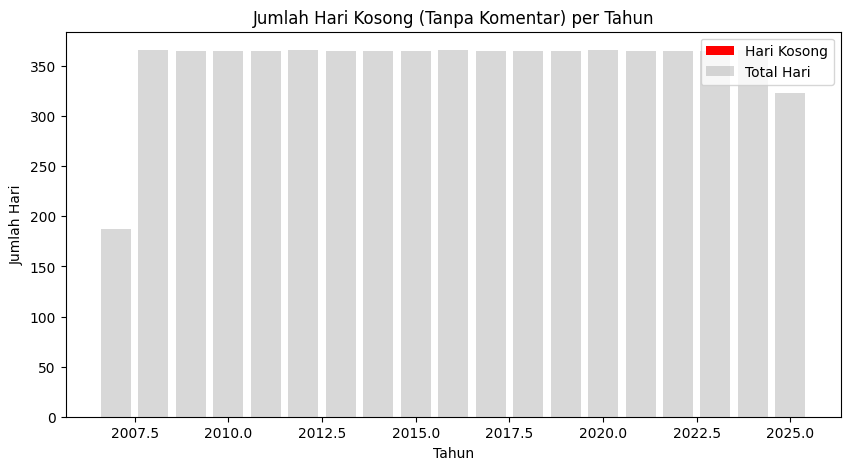

In [20]:
import pandas as pd

# Pastikan menggunakan variabel df_full Anda
DATE_COL = 'published_at'
SCORE_COL = 'sentiment_score'

# 1. Pastikan Format Tanggal Benar
df_full[DATE_COL] = pd.to_datetime(df_full[DATE_COL])

# 2. Resample ke Harian (Membuat kalender lengkap dari tanggal pertama s/d terakhir)
# Kita pakai .mean() -> Jika hari itu tidak ada komentar, hasilnya jadi NaN (Not a Number)
df_daily_check = df_full.set_index(DATE_COL).resample('D')[SCORE_COL].mean()

# 3. Buat DataFrame Analisis
df_audit = pd.DataFrame({
    'Tanggal': df_daily_check.index,
    'Is_Missing': df_daily_check.isna(), # True jika kosong (NaN), False jika ada data
    'Year': df_daily_check.index.year
})

# 4. Hitung Statistik per Tahun
yearly_stats = df_audit.groupby('Year')['Is_Missing'].agg(['count', 'sum'])

# Rename kolom biar enak dibaca
yearly_stats.columns = ['Total_Hari', 'Hari_Kosong']

# Hitung Persentase Kekosongan
yearly_stats['Persen_Kosong'] = round((yearly_stats['Hari_Kosong'] / yearly_stats['Total_Hari']) * 100, 2)

# Tambahkan kolom rekomendasi
yearly_stats['Status'] = yearly_stats['Persen_Kosong'].apply(
    lambda x: '💀 DATA MATI' if x > 80 else ('⚠️ DATA JARANG' if x > 30 else '✅ DATA BAGUS')
)

print("--- LAPORAN KUALITAS DATA PER TAHUN ---")
print(yearly_stats)

# --- VISUALISASI BIAR MAKIN JELAS ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
bars = plt.bar(yearly_stats.index, yearly_stats['Hari_Kosong'], color='red', label='Hari Kosong')
plt.bar(yearly_stats.index, yearly_stats['Total_Hari'], alpha=0.3, color='gray', label='Total Hari')

plt.title("Jumlah Hari Kosong (Tanpa Komentar) per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Hari")
plt.legend()
plt.show()

/tmp/ipykernel_48/1697634562.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  volatility_check = df_full.set_index(DATE_COL).resample('Y')[SCORE_COL].std()


--- TINGKAT FLUKTUASI DATA (Standard Deviation) ---
published_at
2007-12-31    0.033641
2008-12-31    0.000000
2009-12-31    0.000000
2010-12-31    0.000000
2011-12-31    0.000000
2012-12-31    0.000000
2013-12-31    0.000000
2014-12-31    0.000000
2015-12-31    0.000000
2016-12-31    0.000000
2017-12-31    0.000000
2018-12-31    0.000000
2019-12-31    0.000000
2020-12-31    0.000000
2021-12-31    0.000000
2022-12-31    0.000000
2023-12-31    0.000000
2024-12-31    0.028030
2025-12-31    0.049439
Freq: YE-DEC, Name: sentiment_score, dtype: float64


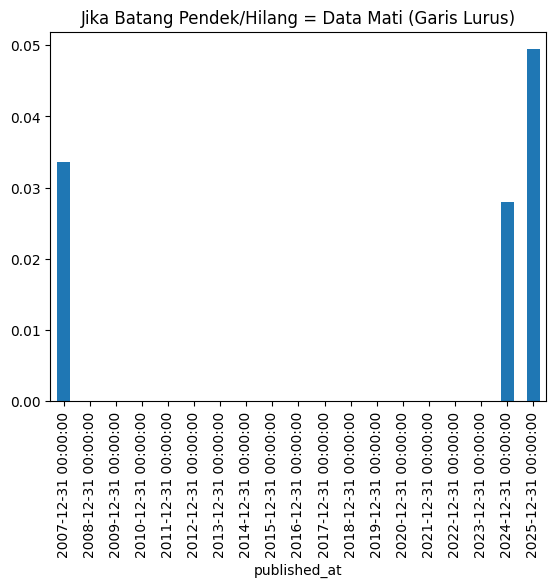

In [21]:
# Hitung Standar Deviasi per Tahun (Seberapa fluktuatif datanya?)
# Jika mendekati 0, berarti itu garis lurus (Flat Line)
volatility_check = df_full.set_index(DATE_COL).resample('Y')[SCORE_COL].std()

print("--- TINGKAT FLUKTUASI DATA (Standard Deviation) ---")
print(volatility_check)

# Plot sederhana
volatility_check.plot(kind='bar', title='Jika Batang Pendek/Hilang = Data Mati (Garis Lurus)')
plt.show()

/tmp/ipykernel_48/2420627960.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.fillna(method='ffill')


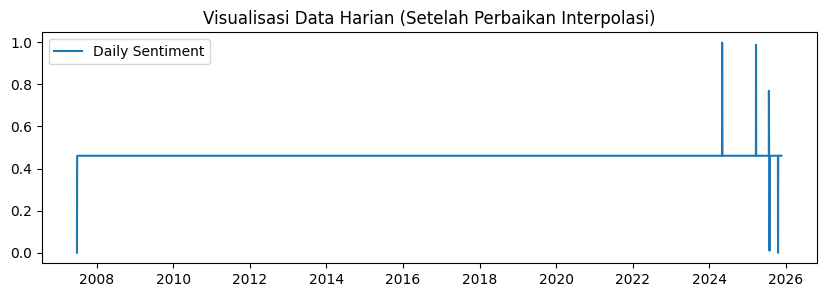

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- KONFIGURASI ---
DATE_COL = 'published_at'  # Pastikan nama kolom tanggal di df_full benar
SCORE_COL = 'sentiment_score' # Kolom angka hasil sentimen sebelumnya
LOOK_BACK = 14  # Melihat 14 hari ke belakang untuk prediksi besok (2 minggu)

# 1. Pastikan Format Tanggal Benar
df_full[DATE_COL] = pd.to_datetime(df_full[DATE_COL])
df_sorted = df_full.sort_values(by=DATE_COL)

# 2. Resampling Harian (Rata-rata per hari)
df_daily = df_sorted.set_index(DATE_COL).resample('D')[SCORE_COL].mean()

# --- PERBAIKAN KRUSIAL DI SINI ---
# JANGAN pakai 'linear', pakai 'ffill' (mengambil nilai hari sebelumnya)
# Jika ada hari kosong, dianggap sentimennya sama dengan hari terakhir.
df_daily = df_daily.fillna(method='ffill') 
# Jika data awal sekali kosong, isi dengan 0
df_daily = df_daily.fillna(0)

# Cek Visual Data (Pastikan tidak terlihat garis lurus panjang yang aneh)
plt.figure(figsize=(10, 3))
plt.plot(df_daily.index, df_daily.values, label='Daily Sentiment')
plt.title("Visualisasi Data Harian (Setelah Perbaikan Interpolasi)")
plt.legend()
plt.show()

# Siapkan Dataset Numpy
dataset = df_daily.values.reshape(-1, 1)

Total data points (hari): 6720
Data Training: (5351, 30, 1), Data Testing: (1338, 30, 1)


I0000 00:00:1763793286.318925      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12234 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763793286.319666      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 12242 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1763793290.769902   11076 cuda_dnn.cc:529] Loaded cuDNN version 90300


168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0213 - val_loss: 8.3546e-04
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7272e-10 - val_loss: 8.3547e-04
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1925e-11 - val_loss: 8.3547e-04
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9919e-10 - val_loss: 8.3547e-04
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4208e-10 - val_loss: 8.3547e-04
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.7214e-11 - val_loss: 8.3547e-04
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.9595e-11 - val_loss: 8.3547e-04
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.0264e-12 - val_loss: 8.3547e-04
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6927e-10 - val_loss: 8.3547e-04
Epoch 10/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.5620e-10 - val_loss: 8.3547e-04
Epoch 11/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4993e-11 -

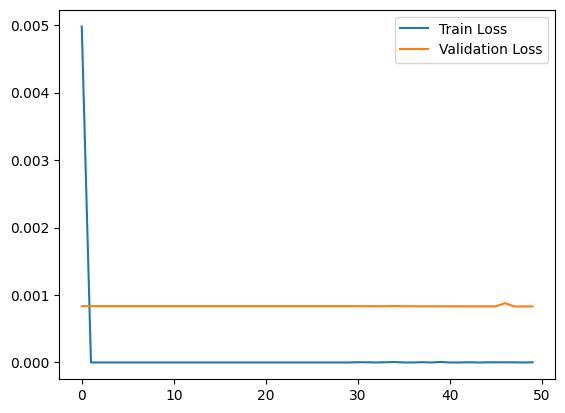

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ==========================================
# 1. PERSIAPAN DATA (GROUPING BY TIME)
# ==========================================
# Pastikan ada kolom tanggal, misal 'published_at' atau 'date'
# Ganti 'date_column' dengan nama kolom tanggal di data Anda
date_col = 'published_at'  
score_col = 'sentiment_score' # Kolom angka yang mau diprediksi

# Konversi ke datetime dan urutkan
df_full[date_col] = pd.to_datetime(df_full[date_col])
df_sorted = df_full.sort_values(by=date_col)

# Kita harus buat data harian/mingguan (Resampling)
# 'D' = Daily (Harian), 'W' = Weekly (Mingguan)
# Kita ambil rata-rata skor sentimen per hari
df_daily = df_sorted.set_index(date_col).resample('D')[score_col].mean()

# Isi data kosong (jika ada hari tanpa komentar) dengan interpolasi
df_daily = df_daily.interpolate(method='linear')

# Data siap (Array 1 dimensi)
dataset = df_daily.values.reshape(-1, 1)

print(f"Total data points (hari): {len(dataset)}")

# ==========================================
# 2. NORMALISASI & PREPROCESSING
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Fungsi membuat Sliding Window
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# --- SETTING PENTING ---
LOOK_BACK = 30  # Kita memprediksi berdasarkan 30 hari sebelumnya
# -----------------------

X, y = create_dataset(scaled_data, LOOK_BACK)

# Reshape input untuk LSTM [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split Train & Test (Jangan diacak/shuffle, harus urut waktu!)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Data Training: {X_train.shape}, Data Testing: {X_test.shape}")
# ==========================================
# 3. MEMBANGUN MODEL LSTM (REGRESSION)
# ==========================================
model = Sequential()

# Layer LSTM
model.add(LSTM(50, return_sequences=True, input_shape=(LOOK_BACK, 1)))
model.add(LSTM(50))

# Output Layer (1 neuron untuk prediksi angka)
model.add(Dense(1)) 

model.compile(loss='mean_squared_error', optimizer='adam')

# Training
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_test, y_test), 
                    verbose=1)

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# PAKAI DATASET BARU

In [2]:
!pip install langdetect
!pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.1 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f1741e17d7e04b6326ee915b8ffd31a768325e9768bab53ee7ac3a3e863d1b47
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [5]:
import pandas as pd
import re
import nltk
from langdetect import detect, LangDetectException
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download resource NLTK (cukup sekali run)
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

# ==========================================
# 1. SETUP
# ==========================================
INPUT_FILE = "/kaggle/input/data-komentar/comments_filtered_final.csv"
OUTPUT_FILE = "komentar_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

# Pastikan kolom text string
df['comment_text'] = df['comment_text'].astype(str)

print(f"Total Data Awal: {len(df)}")

# Inisialisasi Lemmatizer
lemmatizer = WordNetLemmatizer()

# ==========================================
# 2. FUNGSI-FUNGSI PEMBERSIH
# ==========================================

def filter_language(text):
    """Hanya loloskan Bahasa Inggris"""
    try:
        # Deteksi bahasa
        lang = detect(text)
        if lang == 'en':
            return True
    except LangDetectException:
        # Jika teks isinya cuma simbol/angka, detect akan error
        pass
    return False

def clean_text_advanced(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Hapus URL (http/https/www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Hapus Mention (@username) dan Hashtag (#topic)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # 4. Hapus Angka (Opsional: aktifkan jika angka tidak penting untuk sentimen)
    # text = re.sub(r'\d+', '', text) 
    
    # 5. Hapus Simbol Aneh (Sisakan huruf, angka, dan spasi)
    # Kita pertahankan apostrof ' agar "don't" tidak jadi "dont" dulu (bisa dihandle nanti)
    text = re.sub(r'[^\w\s\']', ' ', text)
    
    # 6. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def lemmatize_sentence(text):
    """
    Mengubah 'cars' -> 'car', 'driving' -> 'drive', 'better' -> 'good'
    """
    words = text.split()
    # Lemmatization sederhana (tanpa POS tagging biar cepat)
    # Mengubah kata kerja (v) ke bentuk dasar
    lemmed_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    return " ".join(lemmed_words)

# ==========================================
# 3. EKSEKUSI
# ==========================================

# A. Filter Bahasa (Mungkin agak lama jika data ribuan)
print("Sedang memfilter bahasa (Hanya Inggris)...")
# Kita pakai apply tapi dicek dulu biar ga berat
df['is_english'] = df['comment_text'].apply(filter_language)
df_english = df[df['is_english'] == True].copy()

print(f"Data setelah filter bahasa: {len(df_english)} (Dibuang: {len(df) - len(df_english)})")

# B. Cleaning Regex
print("Sedang membersihkan simbol & noise...")
df_english['clean_text'] = df_english['comment_text'].apply(clean_text_advanced)

# C. Lemmatization
print("Sedang melakukan Lemmatization (Menyeragamkan kata)...")
df_english['clean_text'] = df_english['clean_text'].apply(lemmatize_sentence)

# D. Hapus data kosong setelah cleaning
df_english = df_english[df_english['clean_text'].str.len() > 3]

# ==========================================
# 4. SIMPAN
# ==========================================
# Kita hanya simpan kolom penting
final_cols = ['video_id', 'clean_text', 'published_at', 'like_count']
df_english[final_cols].to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ SELESAI! Data bersih tersimpan di: {OUTPUT_FILE}")
print(df_english[['clean_text']].head(10))

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Total Data Awal: 135965
Sedang memfilter bahasa (Hanya Inggris)...
Data setelah filter bahasa: 111363 (Dibuang: 24602)
Sedang membersihkan simbol & noise...
Sedang melakukan Lemmatization (Menyeragamkan kata)...

✅ SELESAI! Data bersih tersimpan di: komentar_cleaned.csv
                                          clean_text
0  why do this guy seem like he be hop this car b...
1  canada want to be a leader in the green transi...
2  will it make it globally yeah asian evs be the...
3  i've drive both taycan and su7 in term of smar...
4  model 3 the base car estimate at 377 miles of ...
5  not good report you ignore or purposely miss t...
6  xiaomi it s a mobile phone company and they st...
7  it s look like a electric porsche tycoon a tes...
8  the appliance and phone company be able to mak...
9  chinese car design and tech be decades ahead o...


In [2]:
pip install protobuf==3.20.3 --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from tqdm import tqdm

# ==========================================
# 1. SETUP MODEL RoBERTa
# ==========================================
MODEL_NAME = f"cardiffnlp/twitter-roberta-base-sentiment"

print("Sedang meload model RoBERTa (Mungkin butuh waktu download di awal)...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Gunakan GPU jika tersedia agar ngebut
# Device check
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device("cuda:0")  # Master device
    multi_gpu = True
    print(f"Multiple GPUs detected: {torch.cuda.device_count()}, using DataParallel")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    multi_gpu = False
    print(f"Using single device: {device}")

# Pakai DataParallel jika ada >1 GPU
if multi_gpu:
    model = torch.nn.DataParallel(model)

model.to(device)
model.eval()
# ==========================================
# 2. LOAD DATA
# ==========================================
INPUT_FILE = "komentar_cleaned.csv" # File hasil cleaning sebelumnya
OUTPUT_FILE = "data_with_sentiment_score.csv"

df = pd.read_csv(INPUT_FILE)
print(f"Total data: {len(df)}")

# ==========================================
# 3. FUNGSI SCORING
# ==========================================
def get_roberta_scores(texts, batch_size=32):
    scores_list = []
    
    # Loop per batch agar RAM tidak meledak
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing Batches"):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenization
        encoded_input = tokenizer(
            batch_texts, 
            return_tensors='pt', 
            padding=True, 
            truncation=True, 
            max_length=512
        ).to(device)
        
        # Prediksi (Forward Pass)
        with torch.no_grad(): # Matikan gradien biar hemat memori
            output = model(**encoded_input)
        
        # Ambil logits dan ubah ke probabilitas (0-1)
        scores = output.logits.detach().cpu().numpy()
        probs = softmax(scores, axis=1) 
        # Urutan probs di model ini: [0=Negative, 1=Neutral, 2=Positive]
        
        # Hitung Compound Score untuk setiap teks di batch ini
        # Rumus: Score = Prob_Positif - Prob_Negatif
        # Rentang hasil: -1 (Sangat Negatif) s/d +1 (Sangat Positif)
        for prob in probs:
            neg = prob[0]
            neu = prob[1]
            pos = prob[2]
            
            compound_score = pos - neg
            scores_list.append(compound_score)
            
    return scores_list

# ==========================================
# 4. EKSEKUSI
# ==========================================

# Pastikan data text berupa list string
texts = df['clean_text'].astype(str).tolist()

# Jalankan Scoring (Batch Size sesuaikan dengan RAM/VRAM. 32 aman untuk CPU/GPU standar)
sentiment_scores = get_roberta_scores(texts, batch_size=32)

# Masukkan ke DataFrame
df['sentiment_score'] = sentiment_scores

# ==========================================
# 5. SIMPAN
# ==========================================
# Simpan kolom yang dibutuhkan untuk LSTM nanti
# Kita butuh 'published_at' dan 'sentiment_score'
final_cols = ['video_id', 'clean_text', 'published_at', 'sentiment_score']
df[final_cols].to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ SELESAI! File tersimpan di: {OUTPUT_FILE}")
print("\nContoh Hasil:")
print(df[['clean_text', 'sentiment_score']].head(10))

Sedang meload model RoBERTa (Mungkin butuh waktu download di awal)...
Multiple GPUs detected: 2, using DataParallel
Total data: 111363



Processing Batches:  83%|████████▎ | 2906/3481 [08:22<01:54,  5.04it/s]


Rentang Data Asli: 2020-09-25 s/d 2025-11-22

=== LAPORAN KELENGKAPAN DATA (MISSING SCORE) ===
      Total_Hari  Hari_Kosong  Persen_Kosong                     Status
Year                                                                   
2020          98           96          97.96  💀 KRITIS (Jangan Dipakai)
2021         365          247          67.67                 ⚠️ WASPADA
2022         365          123          33.70                 ⚠️ WASPADA
2023         365            9           2.47                     ✅ AMAN
2024         366            0           0.00                     ✅ AMAN
2025         326            0           0.00                     ✅ AMAN


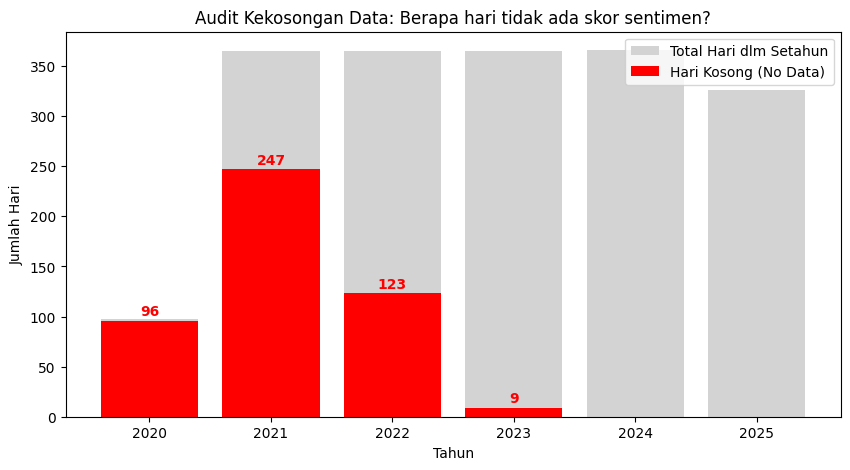

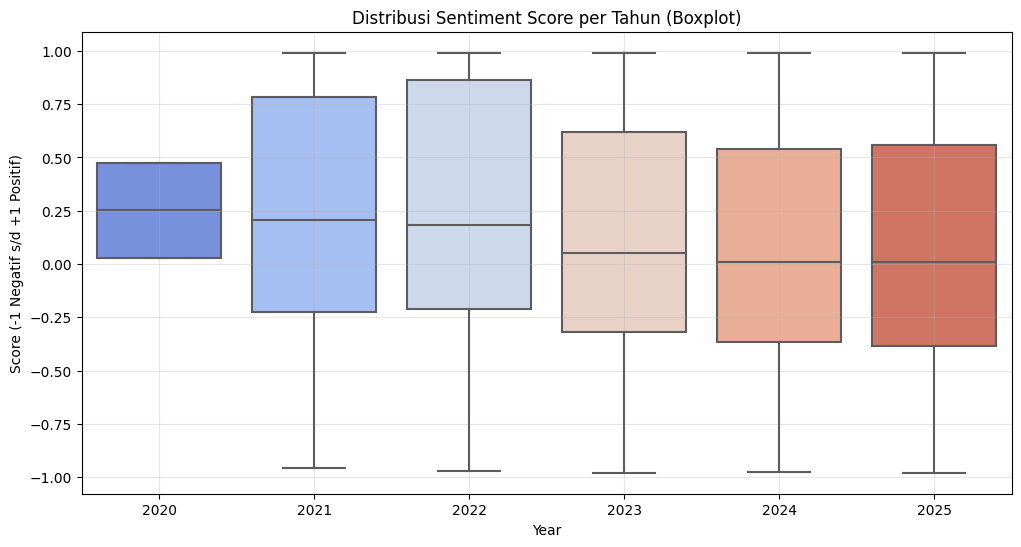

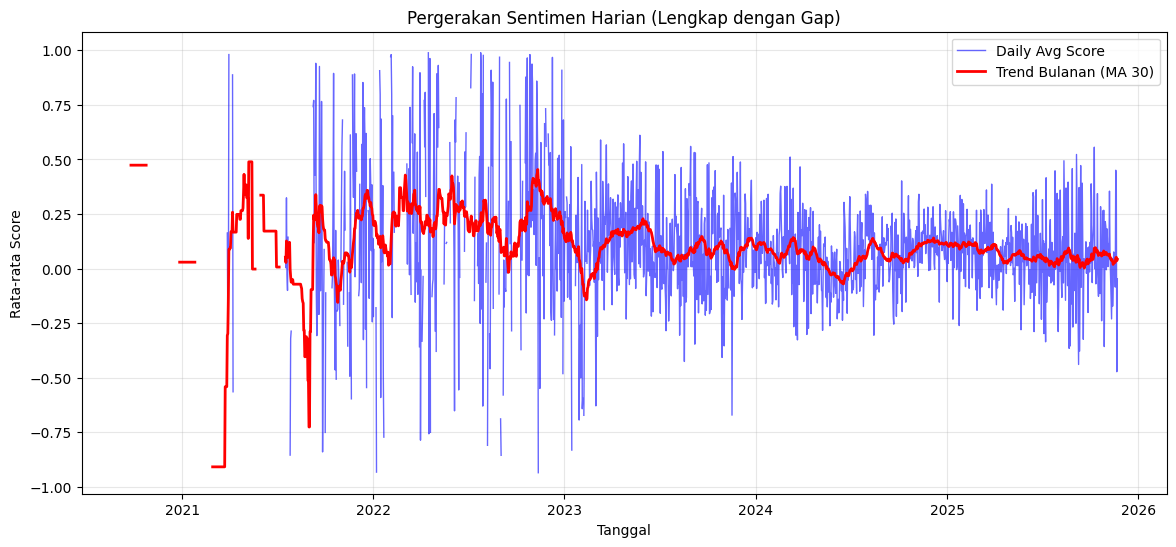

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA
# ==========================================
INPUT_FILE = "data_with_sentiment_score.csv" # File hasil RoBERTa
DATE_COL = "published_at"
SCORE_COL = "sentiment_score"

df = pd.read_csv(INPUT_FILE)

# Konversi ke Datetime dan Hapus Timezone (agar tidak error saat bikin range)
df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.tz_localize(None)

# Kita hanya butuh Tanggal (Jam/Menit dibuang untuk grouping harian)
df['date_only'] = df[DATE_COL].dt.date
df['date_only'] = pd.to_datetime(df['date_only']) # Balikin ke object datetime

print(f"Rentang Data Asli: {df['date_only'].min().date()} s/d {df['date_only'].max().date()}")

# ==========================================
# 2. MEMBUAT KALENDER LENGKAP (FILLING GAPS)
# ==========================================
# Cari tanggal paling awal dan paling akhir di data
min_date = df['date_only'].min()
max_date = df['date_only'].max()

# Buat urutan tanggal lengkap dari min ke max (setiap hari)
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Hitung Rata-rata Score per Hari
# (Hari yang tidak ada komentar akan otomatis hilang di sini)
daily_scores = df.groupby('date_only')[SCORE_COL].mean()

# Reindex: Paksa daily_scores punya index sesuai full_date_range
# Hari yang tadi hilang sekarang akan muncul kembali dengan nilai NaN (Kosong)
daily_scores_full = daily_scores.reindex(full_date_range)

# Buat DataFrame baru untuk analisis
df_audit = pd.DataFrame({
    'Tanggal': daily_scores_full.index,
    'Avg_Score': daily_scores_full.values,
    'Year': daily_scores_full.index.year
})

# Cek apakah hari itu kosong?
df_audit['Is_Missing'] = df_audit['Avg_Score'].isna()

# ==========================================
# 3. HITUNG MISSING VALUE PER TAHUN
# ==========================================
stats = df_audit.groupby('Year').agg(
    Total_Hari=('Is_Missing', 'count'),
    Hari_Kosong=('Is_Missing', 'sum')
)

stats['Persen_Kosong'] = round((stats['Hari_Kosong'] / stats['Total_Hari']) * 100, 2)
stats['Status'] = stats['Persen_Kosong'].apply(
    lambda x: '💀 KRITIS (Jangan Dipakai)' if x > 80 else ('⚠️ WASPADA' if x > 30 else '✅ AMAN')
)

print("\n=== LAPORAN KELENGKAPAN DATA (MISSING SCORE) ===")
print(stats)

# ==========================================
# 4. VISUALISASI 1: KEKOSONGAN DATA
# ==========================================
plt.figure(figsize=(10, 5))
# Plot Total Hari (Background)
plt.bar(stats.index, stats['Total_Hari'], color='lightgray', label='Total Hari dlm Setahun')
# Plot Hari Kosong (Merah)
bars = plt.bar(stats.index, stats['Hari_Kosong'], color='red', label='Hari Kosong (No Data)')

plt.title("Audit Kekosongan Data: Berapa hari tidak ada skor sentimen?")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Hari")
plt.legend()
plt.xticks(stats.index) # Pastikan label tahun muncul semua

# Tambahkan label angka di atas batang merah
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', color='red', fontweight='bold')

plt.show()

# ==========================================
# 5. VISUALISASI 2: SEBARAN SCORE (BOXPLOT)
# ==========================================
# Ini menunjukkan distribusi score asli (sebelum dirata-rata) per tahun
# Apakah tahun 2024 lebih positif dibanding 2023?
df['Year'] = df[DATE_COL].dt.year

plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='sentiment_score', data=df, palette="coolwarm")
plt.title("Distribusi Sentiment Score per Tahun (Boxplot)")
plt.ylabel("Score (-1 Negatif s/d +1 Positif)")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 6. VISUALISASI 3: TREN HARIAN (TIME SERIES)
# ==========================================
# Ini data yang akan dimakan oleh LSTM nanti
plt.figure(figsize=(14, 6))
plt.plot(df_audit['Tanggal'], df_audit['Avg_Score'], label='Daily Avg Score', color='blue', linewidth=1, alpha=0.6)

# Tambahkan garis rata-rata bergerak (Moving Average) biar trend lebih jelas (misal 30 hari)
df_audit['MA_30'] = df_audit['Avg_Score'].rolling(window=30, min_periods=1).mean()
plt.plot(df_audit['Tanggal'], df_audit['MA_30'], label='Trend Bulanan (MA 30)', color='red', linewidth=2)

plt.title("Pergerakan Sentimen Harian (Lengkap dengan Gap)")
plt.xlabel("Tanggal")
plt.ylabel("Rata-rata Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()